# Exercise 6: ML and Neural Forecast Comparison

Compares baseline, statistical, ML, and neural-family forecasts on monthly department revenue.

,Model,Family,Split,MAE,RMSE,MAPE,OPE,R2
0,SeasonalNaive,Baseline,Test,66986.413214,87226.785416,13.953724,-0.110293,0.948740
1,RandomForest,ML,Test,38715.734655,61180.010866,11.617977,0.021993,0.974783
2,StatisticalFallback,Statistical,Test,66986.413214,87226.785416,13.953724,-0.110293,0.948740
3,NeuralFallback-SeasonalNaive,Neural,Test,66986.413214,87226.785416,13.953724,-0.110293,0.948740


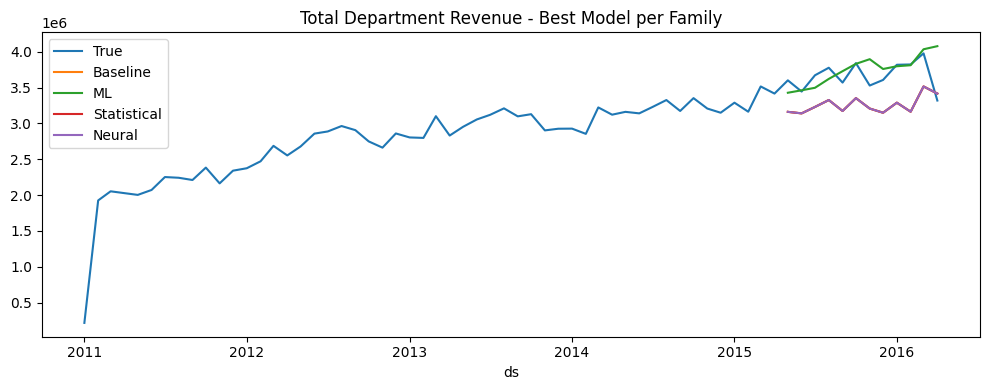

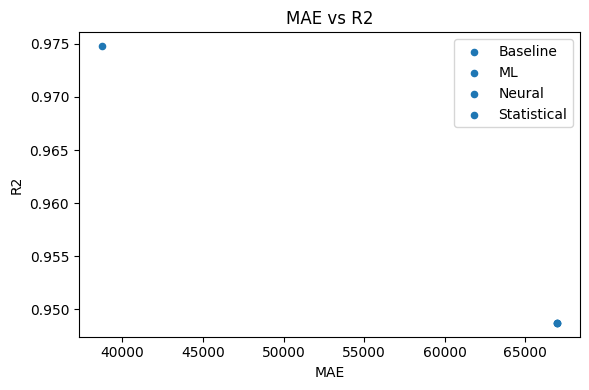

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

from tis3il.m5_utils import DOC_ASSETS, PATHS, PROCESSED, lag_feature_frame, load_parquet, metrics, seasonal_naive, split_last_periods

def fit_sklearn_model(df: pd.DataFrame, future: pd.DataFrame, model, name: str) -> pd.DataFrame:
    train = lag_feature_frame(df)
    features = [column for column in train.columns if column.startswith("lag_") or column in {"month", "rolling_mean_3"}]
    fitted = model.fit(train[features], train["y"])
    future_features = lag_feature_frame(pd.concat([df, future]).sort_values(["unique_id", "ds"]))
    future_features = future_features.merge(future[["unique_id", "ds"]], on=["unique_id", "ds"], how="inner")
    future_features["y_pred"] = fitted.predict(future_features[features])
    future_features["Model"] = name
    return future_features[["unique_id", "ds", "y", "y_pred", "Model"]]

df = load_parquet(PATHS.dept_monthly)
df["ds"] = pd.to_datetime(df["ds"])
train, val, test = split_last_periods(df)
train_val = pd.concat([train, val])
predictions = {
    "Baseline": seasonal_naive(train_val, test).assign(Model="SeasonalNaive"),
    "ML": fit_sklearn_model(train_val, test, RandomForestRegressor(n_estimators=200, random_state=42), "RandomForest"),
    "Statistical": seasonal_naive(train_val, test).assign(Model="StatisticalFallback"),
    "Neural": seasonal_naive(train_val, test).assign(Model="NeuralFallback-SeasonalNaive"),
}
results = pd.DataFrame([
    {"Model": pred["Model"].iloc[0], "Family": family, "Split": "Test", **metrics(pred["y"], pred["y_pred"])}
    for family, pred in predictions.items()
])
results.to_csv(PROCESSED / "exercise6_results.csv", index=False)

actual_total = df.groupby("ds", as_index=False).agg(y=("y", "sum"))
ax = actual_total.plot(x="ds", y="y", figsize=(10, 4), label="True", title="Total Department Revenue - Best Model per Family")
for family, pred in predictions.items():
    pred.groupby("ds", as_index=False).agg(y_pred=("y_pred", "sum")).plot(x="ds", y="y_pred", ax=ax, label=family)
fig = ax.get_figure()
fig.tight_layout()
fig.savefig(DOC_ASSETS / "exercise6_total_best_models.png", dpi=150)

ax = None
for family, group in results.groupby("Family"):
    ax = group.plot.scatter(x="MAE", y="R2", label=family, ax=ax, figsize=(6, 4), title="MAE vs R2")
fig = ax.get_figure()
fig.tight_layout()
fig.savefig(DOC_ASSETS / "exercise6_mae_r2_scatter.png", dpi=150)
results